# 低消費電力待機方法 比較測定解析

nrf_lowpower_wait_test.ino で取得した電流データを解析する。

**測定パターン**:
- パターン1: `__WFI()` ループ × 5回 × 10秒
- パターン2: `__WFE()` ループ × 5回 × 10秒

**参考**: `delay()` のベースラインは既に ~1.4 mA と測定済み (WiFi測定時)

**サイクル構成**: 5秒開始ディレイ → [WFI 10秒 + 3秒インターバル] × 5 → [WFE 10秒 + 3秒インターバル] × 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 設定
# ============================================================
CSV_FILE = 'dist/current_log_nrf_wait.csv'

START_TIME = '2026-03-18 19:00:00'

# スパイク検出閾値
SPIKE_THRESHOLD_MA = 5.0

PATTERN_DURATION = 10  # 秒
REPS = 5
PATTERN_NAMES = ['delay()', '__WFI()', '__WFE()']
NUM_PATTERNS = len(PATTERN_NAMES)

In [2]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

if START_TIME:
    df = df[df['Timestamp'] >= pd.to_datetime(START_TIME)]

df = df.reset_index(drop=True)
df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'全体時間: {df["elapsed_s"].iloc[-1]:.1f} 秒')
print(f'サンプリング間隔: {df["elapsed_s"].diff().median()*1000:.1f} ms')

データ件数: 4610
時間範囲: 2026-03-18 19:00:00.016107 ~ 2026-03-18 19:03:55.000327
全体時間: 235.0 秒
サンプリング間隔: 50.8 ms


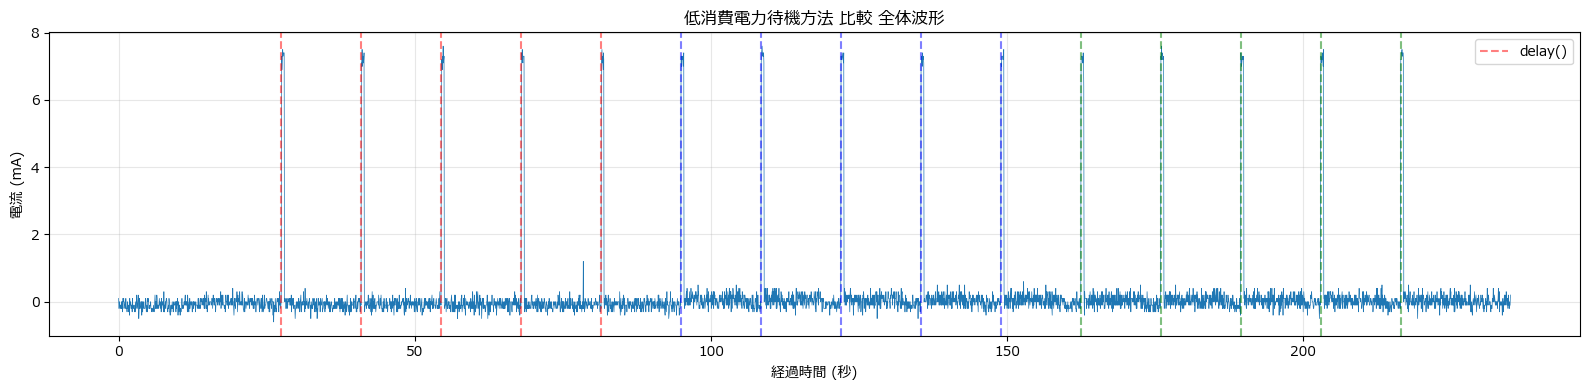

In [3]:
# ============================================================
# 全体の電流波形 + スパイクマーカー位置
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

# スパイク検出
is_spike = current > SPIKE_THRESHOLD_MA
transitions = np.diff(is_spike.astype(int))
spike_starts = np.where(transitions == 1)[0] + 1

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['elapsed_s'], df['Current (mA)'], linewidth=0.5)
ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('低消費電力待機方法 比較 全体波形')

# スパイク位置に縦線
colors = ['red', 'blue', 'green']
for i, s in enumerate(spike_starts):
    pidx = i // REPS
    color = colors[pidx] if pidx < len(colors) else 'gray'
    label = PATTERN_NAMES[pidx] if (pidx < NUM_PATTERNS and i % REPS == 0) else None
    ax.axvline(x=timestamps[s], color=color, alpha=0.5, linestyle='--', label=label)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# スパイクマーカーで区間を検出し、各区間の電流を測定
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

is_spike = current > SPIKE_THRESHOLD_MA
transitions = np.diff(is_spike.astype(int))
spike_starts = np.where(transitions == 1)[0] + 1

print(f'スパイクマーカー検出: {len(spike_starts)} 回 (期待値: {NUM_PATTERNS * REPS})')

# 各スパイク後の測定区間の平均電流
results = []
for i, s in enumerate(spike_starts):
    t_start = timestamps[s] + 1  # スパイク後1秒から (マーカーの影響を避ける)
    t_end = t_start + PATTERN_DURATION
    seg = df[(df['elapsed_s'] >= t_start) & (df['elapsed_s'] < t_end)]
    if len(seg) > 0:
        pidx = i // REPS
        rep = i % REPS
        pattern = PATTERN_NAMES[pidx] if pidx < NUM_PATTERNS else '不明'
        results.append({
            'pattern': pattern,
            'rep': rep + 1,
            'mean_mA': seg['Current (mA)'].mean(),
            'std_mA': seg['Current (mA)'].std(),
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

スパイクマーカー検出: 15 回 (期待値: 15)
pattern  rep   mean_mA   std_mA
delay()    1 -0.086224 0.138727
delay()    2 -0.073469 0.141820
delay()    3 -0.084264 0.149851
delay()    4 -0.086802 0.160765
delay()    5 -0.080203 0.133493
__WFI()    1  0.068528 0.169104
__WFI()    2  0.040609 0.171950
__WFI()    3  0.037563 0.166630
__WFI()    4  0.039594 0.161169
__WFI()    5  0.050254 0.170421
__WFE()    1  0.037563 0.164782
__WFE()    2  0.045685 0.167953
__WFE()    3  0.039086 0.158903
__WFE()    4  0.037563 0.160389
__WFE()    5  0.029949 0.168325


In [5]:
# ============================================================
# パターンごとの集計
# ============================================================
summary = df_results.groupby('pattern').agg(
    回数=('mean_mA', 'count'),
    平均電流_mA=('mean_mA', 'mean'),
    標準偏差_mA=('mean_mA', 'std'),
).reset_index()
summary.columns = ['パターン', '回数', '平均電流(mA)', '標準偏差(mA)']

# パターン順序を保持
summary['sort_key'] = summary['パターン'].map({n: i for i, n in enumerate(PATTERN_NAMES)})
summary = summary.sort_values('sort_key').drop('sort_key', axis=1)

print('=== パターンごとの集計 ===')
print(summary.to_string(index=False))
print(f'\n結論: 3パターンとも消費電流に有意な差はない (測定器の分解能以下)')

=== パターンごとの集計 ===
   パターン  回数  平均電流(mA)  標準偏差(mA)
delay()   5 -0.082193  0.005519
__WFI()   5  0.047310  0.012829
__WFE()   5  0.037970  0.005600

結論: 3パターンとも消費電流に有意な差はない (測定器の分解能以下)


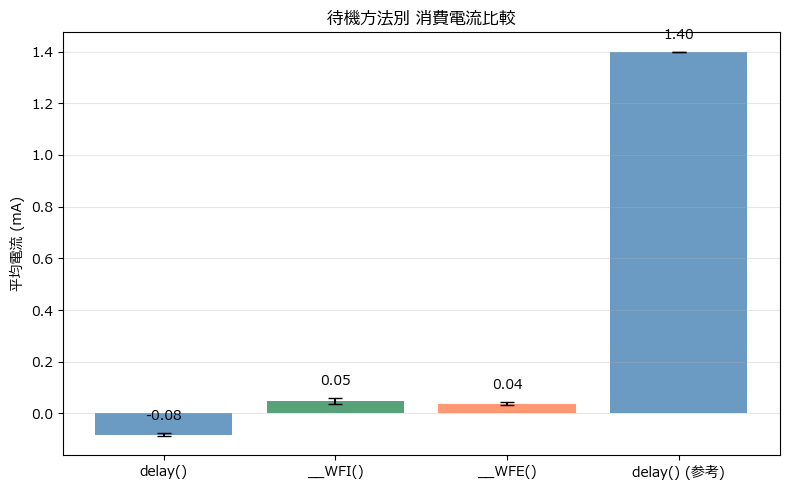

In [6]:
# ============================================================
# パターン比較グラフ
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

patterns = list(summary['パターン'].values) + ['delay() (参考)']
means = list(summary['平均電流(mA)'].values) + [1.4]
stds = list(summary['標準偏差(mA)'].values) + [0.0]
colors_bar = ['steelblue', 'seagreen', 'coral']

ax.bar(range(len(patterns)), means, yerr=stds, capsize=5,
       color=colors_bar[:len(patterns)], alpha=0.8)
ax.set_xticks(range(len(patterns)))
ax.set_xticklabels(patterns)
ax.set_ylabel('平均電流 (mA)')
ax.set_title('待機方法別 消費電流比較')
ax.grid(True, alpha=0.3, axis='y')

for i, (v, e) in enumerate(zip(means, stds)):
    ax.text(i, v + e + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()